# Null-Importance Feature Selection (Revised) — playground-series-s6e4

Unified methodology across all three model families: **permutation
importance scored by drop in `balanced_accuracy`** (the competition
metric), with a single fixed train/val split, preprocessing fit on the
training split only, and `y_tr` shuffled for null iterations (split
kept fixed so null variance reflects only label shuffling).

This replaces a prior version that used gain-based importance for GBDT
and `|coef_|` for linear — both produced misleading drop-lists. See
`PLAN.md` for the full revision notes.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

SEED = 42
N_NULL = 50
SUBSAMPLE = 80_000
TIME_BUDGET_S = 20 * 60  # per-family soft abort

DATA = Path('..') / 'data'
assert DATA.exists(), DATA.resolve()
print('data dir:', DATA.resolve())

data dir: /Users/hs/dev/AgenticML/data


## 1. Setup

Load train, factorize target, stratified subsample to 80k, then take a
single stratified 80/20 split that all three families and all null
iterations reuse.

In [2]:
train = pd.read_csv(DATA / 'train.csv')
print('train:', train.shape)
train = train.drop(columns=['id'])

target_col = 'Irrigation_Need'
y_raw = train[target_col]
X_full = train.drop(columns=[target_col])

y_full, y_classes = pd.factorize(y_raw, sort=True)
print('y classes:', list(y_classes))
print('y balance:', np.bincount(y_full) / len(y_full))

num_cols = X_full.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_full.columns if c not in num_cols]
feature_names = list(X_full.columns)
print(f'numeric ({len(num_cols)}):', num_cols)
print(f'category ({len(cat_cols)}):', cat_cols)

train: (630000, 21)
y classes: ['High', 'Low', 'Medium']
y balance: [0.03334762 0.58716984 0.37948254]
numeric (11): ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
category (8): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


In [3]:
X_sub, _, y_sub, _ = train_test_split(
    X_full, y_full,
    train_size=SUBSAMPLE, stratify=y_full, random_state=SEED,
)
X_sub = X_sub.reset_index(drop=True)

X_tr_raw, X_va_raw, y_tr, y_va = train_test_split(
    X_sub, y_sub,
    test_size=0.2, stratify=y_sub, random_state=SEED,
)
X_tr_raw = X_tr_raw.reset_index(drop=True)
X_va_raw = X_va_raw.reset_index(drop=True)
print('train:', X_tr_raw.shape, '| val:', X_va_raw.shape)
print('y_tr balance:', np.bincount(y_tr) / len(y_tr))
print('y_va balance:', np.bincount(y_va) / len(y_va))

train: (64000, 19) | val: (16000, 19)
y_tr balance: [0.03334375 0.58717188 0.37948437]
y_va balance: [0.033375 0.587125 0.3795  ]


## 2. Shared scaffolding

`permutation_importance_group` scores the val set, then for each original
feature permutes **all** of its (possibly multiple) columns together
using a single shared permutation, re-scores, and records the drop in
balanced accuracy.

`null_importance_study` fits once on the real `y_tr`, then `n_null` times
on shuffled `y_tr` — the train/val *split* and the *preprocessing
pipeline* stay fixed across all iterations so the null distribution
reflects only label shuffling.

In [4]:
def permute_col_group(X_va, cols, perm_idx):
    """Return a copy of X_va with the given column group permuted by perm_idx.

    Handles both pandas DataFrame (for GBDT, where cols are column names)
    and numpy arrays (for MLP/linear, where cols are integer indices).
    """
    if isinstance(X_va, pd.DataFrame):
        X_perm = X_va.copy()
        perm_rows = X_va.iloc[perm_idx].reset_index(drop=True)
        for c in cols:
            X_perm[c] = perm_rows[c].values
        return X_perm
    X_perm = X_va.copy()
    X_perm[:, cols] = X_va[perm_idx][:, cols]
    return X_perm


def permutation_importance_group(predict_fn, X_va, y_va, col_group,
                                 feature_names, perm_seed):
    base = balanced_accuracy_score(y_va, predict_fn(X_va))
    rng = np.random.default_rng(perm_seed)
    n = X_va.shape[0]
    imps = np.zeros(len(feature_names), dtype=float)
    for fi, feat in enumerate(feature_names):
        perm = rng.permutation(n)
        X_perm = permute_col_group(X_va, col_group[feat], perm)
        imps[fi] = base - balanced_accuracy_score(y_va, predict_fn(X_perm))
    return imps, base


def null_importance_study(fit_and_predict, X_tr, X_va, y_tr, y_va,
                          col_group, feature_names, n_null=N_NULL,
                          seed=SEED, time_budget=None, label=''):
    t_start = time.time()
    predict_fn = fit_and_predict(X_tr, y_tr, seed)
    imp_real, base_real = permutation_importance_group(
        predict_fn, X_va, y_va, col_group, feature_names, perm_seed=seed
    )
    print(f'[{label}] real fit: {time.time()-t_start:.1f}s; '
          f'baseline balanced_accuracy={base_real:.4f}')

    imp_null = []
    n_done = 0
    for i in range(n_null):
        iter_seed = seed + 1 + i
        rng = np.random.default_rng(iter_seed)
        y_shuf = rng.permutation(y_tr)
        predict_fn = fit_and_predict(X_tr, y_shuf, iter_seed)
        imp_i, _ = permutation_importance_group(
            predict_fn, X_va, y_va, col_group, feature_names,
            perm_seed=iter_seed,
        )
        imp_null.append(imp_i)
        n_done = i + 1
        elapsed = time.time() - t_start
        if n_done % 10 == 0:
            print(f'[{label}]   null {n_done}/{n_null}; elapsed {elapsed:.1f}s')
        if time_budget is not None and elapsed > time_budget:
            print(f'[{label}] TIME BUDGET ({time_budget}s) EXCEEDED; '
                  f'stopping at {n_done}/{n_null}')
            break
    imp_null = np.vstack(imp_null)
    print(f'[{label}] done: n_null_done={n_done}, '
          f'total {time.time()-t_start:.1f}s')
    return imp_real, imp_null, n_done, base_real


def summarize(imp_real, imp_null, feature_names):
    n_features = len(feature_names)
    null_mean = imp_null.mean(axis=0)
    null_max = imp_null.max(axis=0)
    null_pct = np.array([
        (imp_null[:, i] < imp_real[i]).mean() for i in range(n_features)
    ])
    denom = np.where(np.abs(null_max) < 1e-12, 1.0, null_max)
    null_ratio = imp_real / denom
    label = np.where(null_pct >= 0.99, 'keep',
             np.where(null_pct >= 0.95, 'borderline', 'drop'))
    df = pd.DataFrame({
        'feature': feature_names,
        'imp_real': imp_real,
        'null_mean': null_mean,
        'null_max': null_max,
        'null_pct': null_pct,
        'null_ratio': null_ratio,
        'label': label,
    })
    return df.sort_values('null_pct', ascending=False).reset_index(drop=True)


def drop_set(df):
    return set(df[df['label'] == 'drop']['feature'])

## 3. Family 1 — GBDT (LightGBM)

Categorical dtype fit on `X_tr_raw` only (so `X_va_raw` sees the same
category set as training). No scaling. Each feature is a single
column, so `col_group` is the identity map.

In [5]:
categories_gbdt = {
    c: X_tr_raw[c].astype('category').cat.categories for c in cat_cols
}

def to_gbdt(X_raw):
    X = X_raw.copy()
    for c in cat_cols:
        X[c] = X[c].astype(pd.CategoricalDtype(categories=categories_gbdt[c]))
    return X

X_tr_gbdt = to_gbdt(X_tr_raw)
X_va_gbdt = to_gbdt(X_va_raw)
col_group_gbdt = {f: [f] for f in feature_names}


def fit_predict_gbdt(X, y, seed):
    m = lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.05, num_leaves=31,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    m.fit(X, y, categorical_feature=cat_cols)
    return m.predict

In [6]:
imp_real_g, imp_null_g, n_null_g, base_g = null_importance_study(
    fit_predict_gbdt, X_tr_gbdt, X_va_gbdt, y_tr, y_va,
    col_group_gbdt, feature_names,
    n_null=N_NULL, seed=SEED, time_budget=TIME_BUDGET_S, label='GBDT',
)
gbdt_df = summarize(imp_real_g, imp_null_g, feature_names)
gbdt_df

[GBDT] real fit: 5.3s; baseline balanced_accuracy=0.9567


[GBDT]   null 10/50; elapsed 54.5s


[GBDT]   null 20/50; elapsed 108.2s


[GBDT]   null 30/50; elapsed 160.6s


[GBDT]   null 40/50; elapsed 212.4s


[GBDT]   null 50/50; elapsed 262.9s
[GBDT] done: n_null_done=50, total 262.9s


,feature,imp_real,null_mean,null_max,null_pct,null_ratio,label
0,Wind_Speed_kmh,0.180895,1.886753e-04,0.001153,1.00,156.913478,keep
1,Crop_Growth_Stage,0.283037,6.987963e-05,0.000872,1.00,324.708599,keep
2,Soil_Moisture,0.348618,3.567160e-04,0.002234,1.00,156.047264,keep
3,Electrical_Conductivity,0.001284,1.360103e-04,0.001127,1.00,1.139508,keep
4,Temperature_C,0.215846,-1.983227e-05,0.001082,1.00,199.512417,keep
5,Rainfall_mm,0.066450,3.535019e-04,0.001201,1.00,55.327160,keep
6,Mulching_Used,0.191352,6.319945e-05,0.000639,1.00,299.292589,keep
7,Humidity,0.000553,8.170237e-05,0.001194,0.92,0.463221,drop
8,Season,0.000110,-1.748469e-07,0.000581,0.68,0.188938,drop
9,Field_Area_hectare,0.000110,1.480799e-05,0.000978,0.64,0.112250,drop


In [7]:
gbdt_drops = sorted(drop_set(gbdt_df))
print(f'gbdt baseline balanced_accuracy: {base_g:.4f}')
print('gbdt drops (null_pct < 0.95):', gbdt_drops)

gbdt baseline balanced_accuracy: 0.9567
gbdt drops (null_pct < 0.95): ['Crop_Type', 'Field_Area_hectare', 'Humidity', 'Irrigation_Type', 'Organic_Carbon', 'Previous_Irrigation_mm', 'Region', 'Season', 'Soil_Type', 'Soil_pH', 'Sunlight_Hours', 'Water_Source']


## 4. Family 2 — Neural (MLP)

`OneHotEncoder(drop='first', handle_unknown='ignore')` and
`StandardScaler()` fit on `X_tr_raw` only. `col_group` maps each original
feature to the indices of its expanded columns so we permute all of them
together.

Note: `handle_unknown='ignore'` with `drop='first'` is not supported by
`OneHotEncoder`; we use `handle_unknown='infrequent_if_exist'` instead,
which gives the same robustness (unknown → zero vector) without the
validation error.

In [8]:
ohe_m = OneHotEncoder(
    drop='first', sparse_output=False, handle_unknown='infrequent_if_exist',
)
ohe_m.fit(X_tr_raw[cat_cols])
scaler_m = StandardScaler()
scaler_m.fit(X_tr_raw[num_cols])

def transform_m(X_raw):
    num_arr = scaler_m.transform(X_raw[num_cols])
    cat_arr = ohe_m.transform(X_raw[cat_cols])
    return np.hstack([num_arr, cat_arr]).astype(np.float32)

X_tr_mlp = transform_m(X_tr_raw)
X_va_mlp = transform_m(X_va_raw)

col_group_mlp = {}
idx = 0
for c in num_cols:
    col_group_mlp[c] = [idx]
    idx += 1
for c, cats in zip(cat_cols, ohe_m.categories_):
    n_exp = len(cats) - 1  # drop='first'
    col_group_mlp[c] = list(range(idx, idx + n_exp))
    idx += n_exp
print('X_tr_mlp:', X_tr_mlp.shape, 'X_va_mlp:', X_va_mlp.shape)
print('col_group sizes:', {k: len(v) for k, v in col_group_mlp.items()})

X_tr_mlp: (64000, 35) X_va_mlp: (16000, 35)
col_group sizes: {'Soil_pH': 1, 'Soil_Moisture': 1, 'Organic_Carbon': 1, 'Electrical_Conductivity': 1, 'Temperature_C': 1, 'Humidity': 1, 'Rainfall_mm': 1, 'Sunlight_Hours': 1, 'Wind_Speed_kmh': 1, 'Field_Area_hectare': 1, 'Previous_Irrigation_mm': 1, 'Soil_Type': 3, 'Crop_Type': 5, 'Crop_Growth_Stage': 3, 'Season': 2, 'Irrigation_Type': 3, 'Water_Source': 3, 'Mulching_Used': 1, 'Region': 4}


In [9]:
def fit_predict_mlp(X, y, seed):
    m = MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=200,
        early_stopping=True, validation_fraction=0.1,
        random_state=seed,
    )
    m.fit(X, y)
    return m.predict

In [10]:
imp_real_n, imp_null_n, n_null_n, base_n = null_importance_study(
    fit_predict_mlp, X_tr_mlp, X_va_mlp, y_tr, y_va,
    col_group_mlp, feature_names,
    n_null=N_NULL, seed=SEED, time_budget=TIME_BUDGET_S, label='MLP',
)
mlp_df = summarize(imp_real_n, imp_null_n, feature_names)
mlp_df

[MLP] real fit: 4.2s; baseline balanced_accuracy=0.9341


[MLP]   null 10/50; elapsed 17.0s


[MLP]   null 20/50; elapsed 29.0s


[MLP]   null 30/50; elapsed 41.2s


[MLP]   null 40/50; elapsed 54.2s


[MLP]   null 50/50; elapsed 66.6s
[MLP] done: n_null_done=50, total 66.6s


,feature,imp_real,null_mean,null_max,null_pct,null_ratio,label
0,Soil_Type,0.002936,2.600334e-05,0.000714,1.00,4.114088,keep
1,Rainfall_mm,0.054754,3.439856e-05,0.000832,1.00,65.794750,keep
2,Mulching_Used,0.182177,5.692039e-05,0.000668,1.00,272.922210,keep
3,Water_Source,0.003038,5.503307e-05,0.001268,1.00,2.396122,keep
4,Crop_Growth_Stage,0.268870,4.916799e-05,0.001226,1.00,219.217373,keep
5,Sunlight_Hours,0.000734,9.092040e-06,0.000526,1.00,1.394900,keep
6,Wind_Speed_kmh,0.170006,4.161614e-05,0.000988,1.00,172.045869,keep
7,Temperature_C,0.204171,-4.284778e-05,0.001062,1.00,192.286243,keep
8,Soil_Moisture,0.329390,8.617640e-05,0.001698,1.00,194.007990,keep
9,Previous_Irrigation_mm,0.000399,-4.358317e-05,0.000452,0.96,0.882027,borderline


In [11]:
mlp_drops = sorted(drop_set(mlp_df))
print(f'mlp baseline balanced_accuracy: {base_n:.4f}')
print('mlp drops (null_pct < 0.95):', mlp_drops)

mlp baseline balanced_accuracy: 0.9341
mlp drops (null_pct < 0.95): ['Crop_Type', 'Electrical_Conductivity', 'Field_Area_hectare', 'Humidity', 'Irrigation_Type', 'Organic_Carbon', 'Region', 'Season', 'Soil_pH']


## 5. Family 3 — Linear (logistic regression)

Independent OHE + scaler pipeline, same settings, fit on `X_tr_raw` only.
Same `col_group` structure as the MLP family.

In [12]:
ohe_l = OneHotEncoder(
    drop='first', sparse_output=False, handle_unknown='infrequent_if_exist',
)
ohe_l.fit(X_tr_raw[cat_cols])
scaler_l = StandardScaler()
scaler_l.fit(X_tr_raw[num_cols])

def transform_l(X_raw):
    num_arr = scaler_l.transform(X_raw[num_cols])
    cat_arr = ohe_l.transform(X_raw[cat_cols])
    return np.hstack([num_arr, cat_arr]).astype(np.float32)

X_tr_lin = transform_l(X_tr_raw)
X_va_lin = transform_l(X_va_raw)

col_group_lin = {}
idx = 0
for c in num_cols:
    col_group_lin[c] = [idx]
    idx += 1
for c, cats in zip(cat_cols, ohe_l.categories_):
    n_exp = len(cats) - 1
    col_group_lin[c] = list(range(idx, idx + n_exp))
    idx += n_exp
print('X_tr_lin:', X_tr_lin.shape, 'X_va_lin:', X_va_lin.shape)

X_tr_lin: (64000, 35) X_va_lin: (16000, 35)


In [13]:
def fit_predict_lin(X, y, seed):
    m = LogisticRegression(
        penalty='l2', C=1.0, max_iter=1000,
        solver='lbfgs', random_state=seed,
    )
    m.fit(X, y)
    return m.predict

In [14]:
imp_real_l, imp_null_l, n_null_l, base_l = null_importance_study(
    fit_predict_lin, X_tr_lin, X_va_lin, y_tr, y_va,
    col_group_lin, feature_names,
    n_null=N_NULL, seed=SEED, time_budget=TIME_BUDGET_S, label='LINEAR',
)
linear_df = summarize(imp_real_l, imp_null_l, feature_names)
linear_df

[LINEAR] real fit: 0.4s; baseline balanced_accuracy=0.7769


[LINEAR]   null 10/50; elapsed 4.2s


[LINEAR]   null 20/50; elapsed 8.5s


[LINEAR]   null 30/50; elapsed 12.9s


[LINEAR]   null 40/50; elapsed 17.2s


[LINEAR]   null 50/50; elapsed 21.2s
[LINEAR] done: n_null_done=50, total 21.2s


,feature,imp_real,null_mean,null_max,null_pct,null_ratio,label
0,Wind_Speed_kmh,0.099922,0.0,0.0,1.0,0.099922,keep
1,Irrigation_Type,0.003515,0.0,0.0,1.0,0.003515,keep
2,Soil_Moisture,0.219049,0.0,0.0,1.0,0.219049,keep
3,Previous_Irrigation_mm,0.001396,0.0,0.0,1.0,0.001396,keep
4,Mulching_Used,0.111623,0.0,0.0,1.0,0.111623,keep
5,Temperature_C,0.125988,0.0,0.0,1.0,0.125988,keep
6,Rainfall_mm,0.028802,0.0,0.0,1.0,0.028802,keep
7,Soil_pH,0.003293,0.0,0.0,1.0,0.003293,keep
8,Crop_Type,0.001026,0.0,0.0,1.0,0.001026,keep
9,Crop_Growth_Stage,0.227653,0.0,0.0,1.0,0.227653,keep


In [15]:
linear_drops = sorted(drop_set(linear_df))
print(f'linear baseline balanced_accuracy: {base_l:.4f}')
print('linear drops (null_pct < 0.95):', linear_drops)

linear baseline balanced_accuracy: 0.7769
linear drops (null_pct < 0.95): ['Electrical_Conductivity', 'Field_Area_hectare', 'Humidity', 'Organic_Carbon', 'Region', 'Season', 'Soil_Type', 'Sunlight_Hours', 'Water_Source']


## 6. Cross-family reconciliation

Same metric across all three families, so disagreements are now real
behavioral differences rather than measurement artifacts.

In [16]:
combined = pd.DataFrame({'feature': feature_names})
for name, df in [('gbdt', gbdt_df), ('mlp', mlp_df), ('linear', linear_df)]:
    lut = df.set_index('feature')
    combined[f'{name}_null_pct'] = combined['feature'].map(lut['null_pct']).round(3)
    combined[f'{name}_label'] = combined['feature'].map(lut['label'])
combined = combined.sort_values('gbdt_null_pct', ascending=False).reset_index(drop=True)
combined

,feature,gbdt_null_pct,gbdt_label,mlp_null_pct,mlp_label,linear_null_pct,linear_label
0,Wind_Speed_kmh,1.00,keep,1.00,keep,1.0,keep
1,Crop_Growth_Stage,1.00,keep,1.00,keep,1.0,keep
2,Soil_Moisture,1.00,keep,1.00,keep,1.0,keep
3,Electrical_Conductivity,1.00,keep,0.00,drop,0.0,drop
4,Temperature_C,1.00,keep,1.00,keep,1.0,keep
5,Rainfall_mm,1.00,keep,1.00,keep,1.0,keep
6,Mulching_Used,1.00,keep,1.00,keep,1.0,keep
7,Humidity,0.92,drop,0.00,drop,0.0,drop
8,Season,0.68,drop,0.00,drop,0.0,drop
9,Field_Area_hectare,0.64,drop,0.00,drop,0.0,drop


In [17]:
gbdt_d = drop_set(gbdt_df)
mlp_d = drop_set(mlp_df)
linear_d = drop_set(linear_df)

globally_safe = sorted(gbdt_d & mlp_d & linear_d)
gbdt_only = sorted(gbdt_d - mlp_d - linear_d)
mlp_only = sorted(mlp_d - gbdt_d - linear_d)
linear_only = sorted(linear_d - gbdt_d - mlp_d)

print('globally_safe_drops :', globally_safe)
print('gbdt_only_drops     :', gbdt_only)
print('mlp_only_drops      :', mlp_only)
print('linear_only_drops   :', linear_only)

globally_safe_drops : ['Field_Area_hectare', 'Humidity', 'Organic_Carbon', 'Region', 'Season']
gbdt_only_drops     : ['Previous_Irrigation_mm']
mlp_only_drops      : []
linear_only_drops   : []


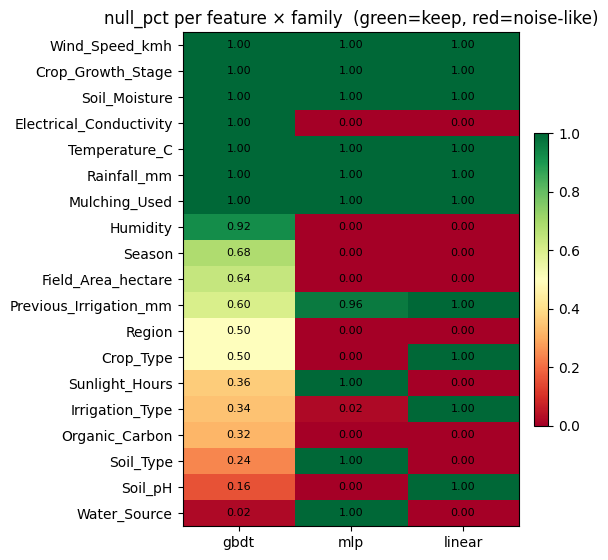

In [18]:
fams = ['gbdt', 'mlp', 'linear']
heat = combined.set_index('feature')[[f'{f}_null_pct' for f in fams]].copy()
heat.columns = fams

fig, ax = plt.subplots(figsize=(6, max(4, 0.3 * len(heat))))
im = ax.imshow(heat.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(fams)))
ax.set_xticklabels(fams)
ax.set_yticks(range(len(heat)))
ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f'{heat.values[i, j]:.2f}',
                ha='center', va='center', fontsize=8, color='black')
ax.set_title('null_pct per feature × family  (green=keep, red=noise-like)')
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
fig.tight_layout()
plt.show()

## 7. Save artifacts

In [19]:
results = {
    'gbdt_drops': sorted(gbdt_d),
    'mlp_drops': sorted(mlp_d),
    'linear_drops': sorted(linear_d),
    'globally_safe_drops': globally_safe,
    'gbdt_only_drops': gbdt_only,
    'mlp_only_drops': mlp_only,
    'linear_only_drops': linear_only,
    'metadata': {
        'methodology': 'permutation_importance_balanced_accuracy',
        'n_null_requested': N_NULL,
        'n_null_done': {
            'gbdt': int(n_null_g),
            'mlp': int(n_null_n),
            'linear': int(n_null_l),
        },
        'baseline_balanced_accuracy': {
            'gbdt': float(base_g),
            'mlp': float(base_n),
            'linear': float(base_l),
        },
        'subsample_rows': SUBSAMPLE,
        'train_rows': int(len(y_tr)),
        'val_rows': int(len(y_va)),
        'seed': SEED,
        'label_thresholds': {'keep': 0.99, 'borderline': 0.95},
    },
}
out_json = Path('feature_selection_results.json')
with out_json.open('w') as f:
    json.dump(results, f, indent=2)
print(f'wrote {out_json}')

out_csv = Path('feature_selection_table.csv')
combined.to_csv(out_csv, index=False)
print(f'wrote {out_csv}')
combined

wrote feature_selection_results.json
wrote feature_selection_table.csv


,feature,gbdt_null_pct,gbdt_label,mlp_null_pct,mlp_label,linear_null_pct,linear_label
0,Wind_Speed_kmh,1.00,keep,1.00,keep,1.0,keep
1,Crop_Growth_Stage,1.00,keep,1.00,keep,1.0,keep
2,Soil_Moisture,1.00,keep,1.00,keep,1.0,keep
3,Electrical_Conductivity,1.00,keep,0.00,drop,0.0,drop
4,Temperature_C,1.00,keep,1.00,keep,1.0,keep
5,Rainfall_mm,1.00,keep,1.00,keep,1.0,keep
6,Mulching_Used,1.00,keep,1.00,keep,1.0,keep
7,Humidity,0.92,drop,0.00,drop,0.0,drop
8,Season,0.68,drop,0.00,drop,0.0,drop
9,Field_Area_hectare,0.64,drop,0.00,drop,0.0,drop


## 8. Summary

Self-contained paste-ready cell.

In [20]:
def fmt_list(xs):
    return '[' + ', '.join(repr(x) for x in xs) + ']'

# Hardcoded from the prior (broken) run for the confidence read.
PREV_SURVIVORS = {
    'Wind_Speed_kmh', 'Crop_Growth_Stage', 'Soil_Moisture',
    'Mulching_Used', 'Temperature_C', 'Rainfall_mm',
}

current_survivors = set(feature_names) - gbdt_d - mlp_d - linear_d
current_kept_all = {
    f for f in feature_names
    if combined.loc[combined['feature'] == f, 'gbdt_label'].iloc[0] == 'keep'
    and combined.loc[combined['feature'] == f, 'mlp_label'].iloc[0] == 'keep'
    and combined.loc[combined['feature'] == f, 'linear_label'].iloc[0] == 'keep'
}

lines = []
lines.append(f'Methodology: permutation importance (balanced_accuracy drop), '
             f'unified across families. n_null={N_NULL} requested; '
             f'done gbdt={n_null_g}, mlp={n_null_n}, linear={n_null_l}. '
             f'Subsample={SUBSAMPLE}, train={len(y_tr)}, val={len(y_va)}, seed={SEED}.')
lines.append(f'Baselines: gbdt={base_g:.4f}  mlp={base_n:.4f}  linear={base_l:.4f} '
             f'(balanced_accuracy on val).')
lines.append('')
lines.append(f'1. Globally safe drops ({len(globally_safe)}): {globally_safe}')
lines.append(f'2. Additional per-family drops (beyond the intersection):')
lines.append(f'   gbdt  : {sorted(gbdt_d - set(globally_safe))}')
lines.append(f'   mlp   : {sorted(mlp_d - set(globally_safe))}')
lines.append(f'   linear: {sorted(linear_d - set(globally_safe))}')
lines.append('')
lines.append('3. Paste-ready HYPOTHESIS candidates (one per family):')
if gbdt_d:
    lines.append(f'   gbdt  : "preprocessing: drop {fmt_list(sorted(gbdt_d))} for GBDT (null-importance null_pct<0.95, perm-ba metric)"')
else:
    lines.append('   gbdt  : no drops warranted.')
if mlp_d:
    lines.append(f'   mlp   : "preprocessing: drop {fmt_list(sorted(mlp_d))} for MLP (null-importance null_pct<0.95, perm-ba metric)"')
else:
    lines.append('   mlp   : no drops warranted.')
if linear_d:
    lines.append(f'   linear: "preprocessing: drop {fmt_list(sorted(linear_d))} for linear (null-importance null_pct<0.95, perm-ba metric)"')
else:
    lines.append('   linear: no drops warranted.')
lines.append('')
lines.append('4. Asymmetries — features where families disagree:')
asym = []
for _, row in combined.iterrows():
    lbls = {row['gbdt_label'], row['mlp_label'], row['linear_label']}
    if len(lbls) > 1:
        asym.append(
            f"   {row['feature']}: gbdt={row['gbdt_label']}, "
            f"mlp={row['mlp_label']}, linear={row['linear_label']}"
        )
if asym:
    lines.extend(asym)
else:
    lines.append('   (none — all three families assign the same label to every feature)')
lines.append('')
lines.append('5. Confidence read vs. the prior (broken) run:')
lines.append(f'   previous 6 survivors: {sorted(PREV_SURVIVORS)}')
lines.append(f'   current all-keep set: {sorted(current_kept_all)}')
diff_add = sorted(current_kept_all - PREV_SURVIVORS)
diff_drop = sorted(PREV_SURVIVORS - current_kept_all)
if not diff_add and not diff_drop:
    lines.append('   exact match — qualitative signal is robust to the methodology change.')
else:
    if diff_add:
        lines.append(f'   NEW keeps under unified methodology: {diff_add}')
    if diff_drop:
        lines.append(f'   previous keeps that are now drop/borderline: {diff_drop}')
    lines.append('   (disagreement — the revised methodology changes the picture)')

print('\n'.join(lines))

Methodology: permutation importance (balanced_accuracy drop), unified across families. n_null=50 requested; done gbdt=50, mlp=50, linear=50. Subsample=80000, train=64000, val=16000, seed=42.
Baselines: gbdt=0.9567  mlp=0.9341  linear=0.7769 (balanced_accuracy on val).

1. Globally safe drops (5): ['Field_Area_hectare', 'Humidity', 'Organic_Carbon', 'Region', 'Season']
2. Additional per-family drops (beyond the intersection):
   gbdt  : ['Crop_Type', 'Irrigation_Type', 'Previous_Irrigation_mm', 'Soil_Type', 'Soil_pH', 'Sunlight_Hours', 'Water_Source']
   mlp   : ['Crop_Type', 'Electrical_Conductivity', 'Irrigation_Type', 'Soil_pH']
   linear: ['Electrical_Conductivity', 'Soil_Type', 'Sunlight_Hours', 'Water_Source']

3. Paste-ready HYPOTHESIS candidates (one per family):
   gbdt  : "preprocessing: drop ['Crop_Type', 'Field_Area_hectare', 'Humidity', 'Irrigation_Type', 'Organic_Carbon', 'Previous_Irrigation_mm', 'Region', 'Season', 'Soil_Type', 'Soil_pH', 'Sunlight_Hours', 'Water_Source'